## Superstore Sales Analysis Notebook

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
%config InlineBackend.figure_format = 'retina'

In [2]:
df = pd.read_excel('../datasets/Superstores Sales/superstore_sales.xlsx')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-08-11 00:00:00,2017-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-08-11 00:00:00,2017-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-12-06 00:00:00,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-11-10 00:00:00,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-11-10 00:00:00,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape

(9800, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [7]:
df['Postal Code'].isnull().sum()

11

In [8]:
df[df['Postal Code'].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,2018-05-12 00:00:00,2018-10-12 00:00:00,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,2016-07-11 00:00:00,2016-09-11 00:00:00,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,2017-06-04 00:00:00,2017-10-04 00:00:00,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


In [9]:
df['Postal Code'] = df['Postal Code'].fillna('05401')

In [10]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [11]:
print(df[['Order Date', 'Ship Date']].sample(10, random_state=42))

               Order Date            Ship Date
532   2018-07-09 00:00:00  2018-11-09 00:00:00
872   2015-10-12 00:00:00           15/12/2015
1149  2016-04-04 00:00:00  2016-04-04 00:00:00
2287  2018-01-06 00:00:00  2018-05-06 00:00:00
4038           29/12/2015  2016-02-01 00:00:00
1726           19/12/2016           20/12/2016
4989           31/08/2018  2018-04-09 00:00:00
4228           24/03/2017           26/03/2017
6664           26/10/2018  2018-01-11 00:00:00
7598           17/09/2015           22/09/2015


In [12]:
# clean up any accidental leading/trailing whitespace in the date columns
df['Order Date'] = df['Order Date'].astype(str).str.strip()
df['Ship Date'] = df['Ship Date'].astype(str).str.strip()

In [13]:
# df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
# df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')

df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', errors='coerce')

In [14]:
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   object        
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [16]:
total_duplicates = df.duplicated().sum()
print(f'Total duplicate rows: {total_duplicates}')

Total duplicate rows: 0


In [17]:
subset_duplicates = df.duplicated(subset=['Order ID', 'Product ID']).sum()
print(f'Duplicate rows based on Order ID and Product ID: {subset_duplicates}')

Duplicate rows based on Order ID and Product ID: 8


In [18]:
duplicated_mask = df.duplicated(subset=['Order ID', 'Product ID'], keep=False)
duplicated_rows = df[duplicated_mask].sort_values(by=['Order ID', 'Product ID'])
print(duplicated_rows[['Order ID', 'Product ID']].head(20))

            Order ID       Product ID
6498  CA-2016-103135  OFF-BI-10000069
6500  CA-2016-103135  OFF-BI-10000069
350   CA-2017-129714  OFF-PA-10001970
352   CA-2017-129714  OFF-PA-10001970
1300  CA-2017-137043  FUR-FU-10003664
1301  CA-2017-137043  FUR-FU-10003664
9168  CA-2017-140571  OFF-PA-10001954
9169  CA-2017-140571  OFF-PA-10001954
7881  CA-2018-118017  TEC-AC-10002006
7882  CA-2018-118017  TEC-AC-10002006
3183  CA-2018-152912  OFF-ST-10003208
3184  CA-2018-152912  OFF-ST-10003208
3405  US-2015-150119  FUR-CH-10002965
3406  US-2015-150119  FUR-CH-10002965
430   US-2017-123750  TEC-AC-10004659
431   US-2017-123750  TEC-AC-10004659


In [19]:
display(duplicated_rows[['Order ID', 'Product ID', 'Order Date', 'Ship Date', 'Product Name', 'Ship Mode', 'Sales']])

,Order ID,Product ID,Order Date,Ship Date,Product Name,Ship Mode,Sales
6498,CA-2016-103135,OFF-BI-10000069,2016-07-24,2016-07-28,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",Standard Class,135.090
6500,CA-2016-103135,OFF-BI-10000069,2016-07-24,2016-07-28,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",Standard Class,90.060
350,CA-2017-129714,OFF-PA-10001970,2017-01-09,2017-03-09,Xerox 1881,First Class,24.560
352,CA-2017-129714,OFF-PA-10001970,2017-01-09,2017-03-09,Xerox 1881,First Class,49.120
1300,CA-2017-137043,FUR-FU-10003664,2017-12-23,2017-12-25,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",Second Class,572.760
1301,CA-2017-137043,FUR-FU-10003664,2017-12-23,2017-12-25,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",Second Class,286.380
9168,CA-2017-140571,OFF-PA-10001954,2017-03-15,2017-03-19,Xerox 1964,Standard Class,319.760
9169,CA-2017-140571,OFF-PA-10001954,2017-03-15,2017-03-19,Xerox 1964,Standard Class,45.680
7881,CA-2018-118017,TEC-AC-10002006,2018-03-12,2018-06-12,Memorex Micro Travel Drive 16 GB,Second Class,76.752
7882,CA-2018-118017,TEC-AC-10002006,2018-03-12,2018-06-12,Memorex Micro Travel Drive 16 GB,Second Class,102.336


##### Code to safely clean the inaccurate entries
##### Steps
* check the shape before cleaning
* drop rows only where the 'Order Id', 'Product Id', and 'Sales' values are identical while keeping the distinct sales rows
* check the shape after cleaning
 
```
print(f"Shape before cleaning: {df.shape}")
df_cleaned = df.drop_duplicates(subset=['Order Id', 'Product Id', 'Sales'], keep='first')
print(f"Shape after cleaning: {df_cleaned.shape})
```

In [20]:
missing_order_dates = df['Order Date'].isna().sum()
print(f'Total rows with missing Order Date: {missing_order_dates}')

Total rows with missing Order Date: 0


In [21]:
missing_ship_dates = df['Ship Date'].isna().sum()
print(f'Total rows with missing Ship Date: {missing_ship_dates}')

Total rows with missing Ship Date: 0


In [22]:
missing_df = df[df['Order Date'].isna()]
display(missing_df[['Order Date', 'Ship Date', 'Customer Name', 'Product Name', 'Sales']].head())

,Order Date,Ship Date,Customer Name,Product Name,Sales


In [23]:
df.sort_values(by=['Order Date', 'Ship Date']).head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
540,541,CA-2015-140795,2015-01-02,2015-03-02,First Class,BD-11500,Bradley Drucker,Consumer,United States,Green Bay,Wisconsin,54302.0,Central,TEC-AC-10001432,Technology,Accessories,Enermax Aurora Lite Keyboard,468.900
5713,5714,US-2015-143707,2015-01-03,2015-05-03,Standard Class,HR-14770,Hallie Redmond,Home Office,United States,New York City,New York,10035.0,East,TEC-PH-10003655,Technology,Phones,Sannysis Cute Owl Design Soft Skin Case Cover ...,5.940
6547,6548,CA-2015-113880,2015-01-03,2015-05-03,Standard Class,VF-21715,Vicky Freymann,Home Office,United States,Elmhurst,Illinois,60126.0,Central,FUR-CH-10000863,Furniture,Chairs,Novimex Swivel Fabric Task Chair,634.116
6548,6549,CA-2015-113880,2015-01-03,2015-05-03,Standard Class,VF-21715,Vicky Freymann,Home Office,United States,Elmhurst,Illinois,60126.0,Central,OFF-PA-10003036,Office Supplies,Paper,"Black Print Carbonless 8 1/2"" x 8 1/4"" Rapid M...",17.472
7947,7948,CA-2015-131009,2015-01-03,2015-05-03,Standard Class,SC-20380,Shahid Collister,Consumer,United States,El Paso,Texas,79907.0,Central,OFF-FA-10004395,Office Supplies,Fasteners,Plymouth Boxed Rubber Bands by Plymouth,18.840


In [24]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64

<Axes: title={'center': 'Ship Mode Distribution'}, ylabel='count'>

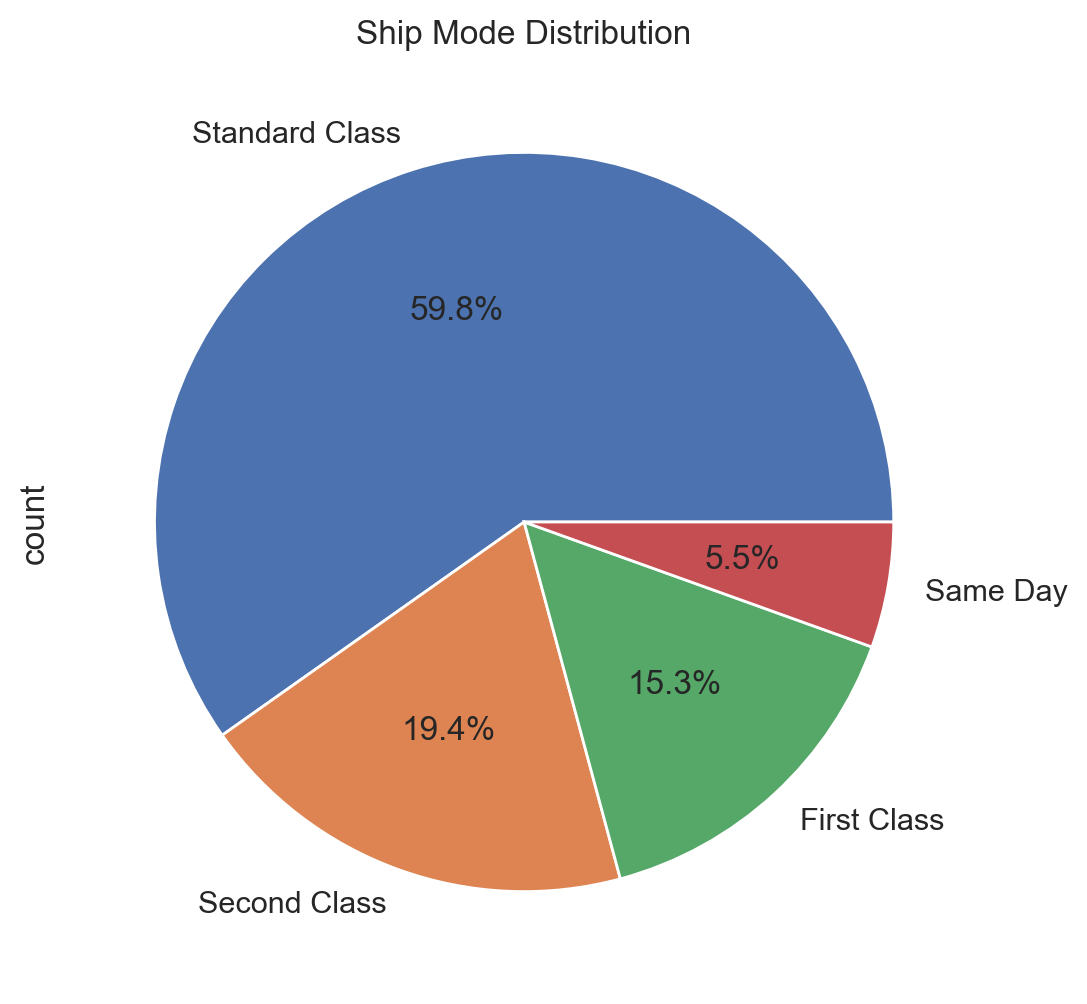

In [25]:
df['Ship Mode'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), title='Ship Mode Distribution')

<Axes: title={'center': 'Segment Distribution'}, xlabel='Segment'>

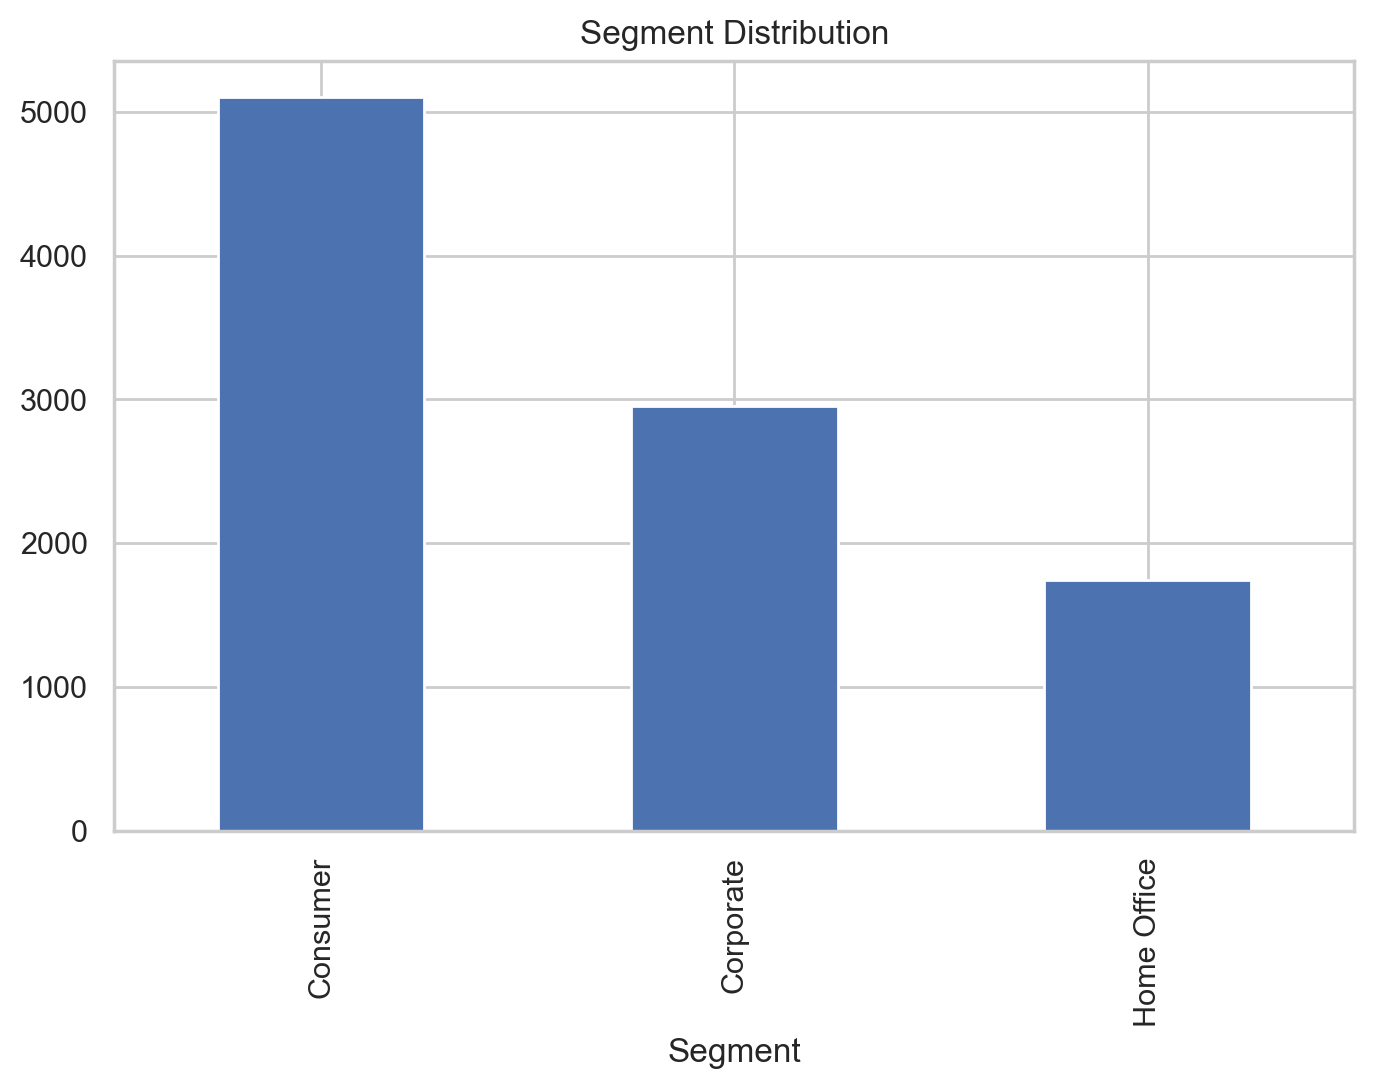

In [26]:
df['Segment'].value_counts().plot(kind='bar', figsize=(8, 5), title='Segment Distribution')

<Axes: title={'center': 'Segment Distribution'}, ylabel='count'>

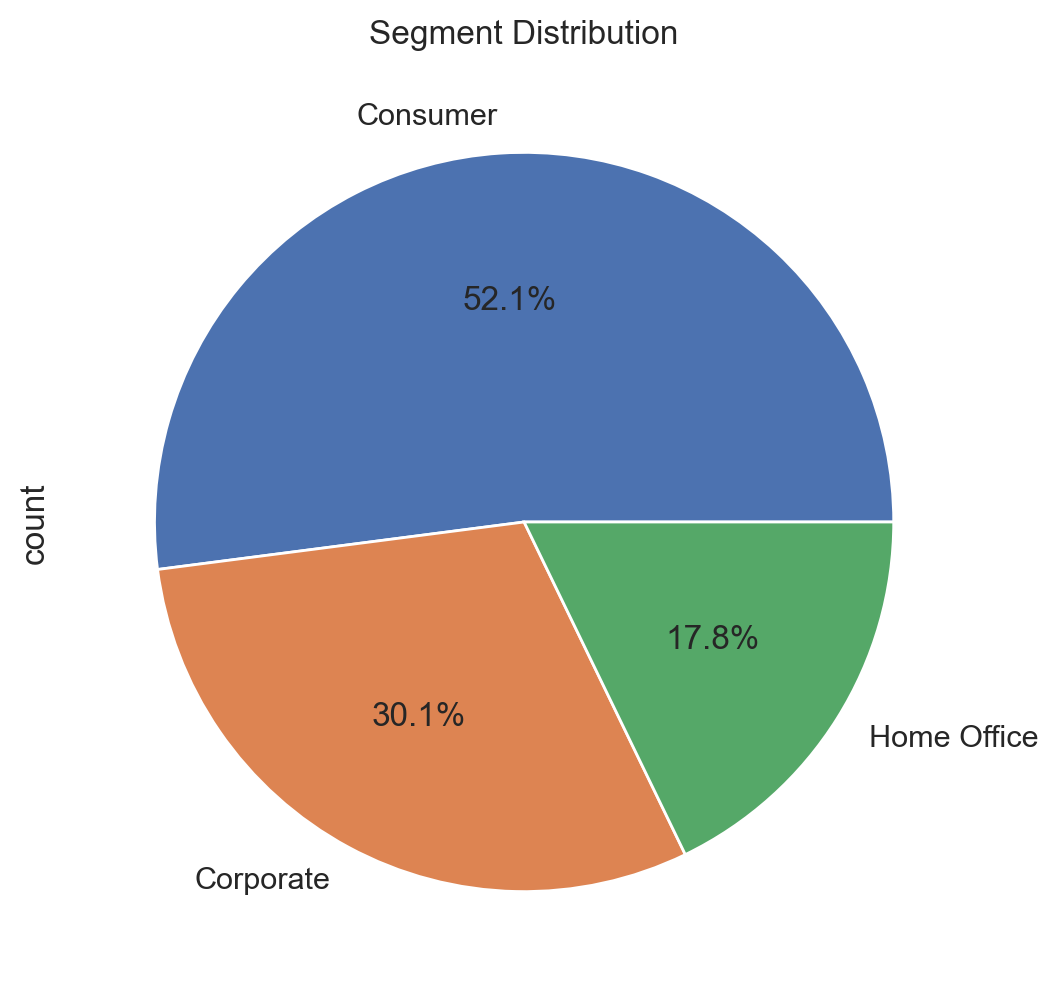

In [27]:
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), title='Segment Distribution')

##### Top sales by state

In [28]:
top_stats = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).round(2)
top_stats = top_stats.reset_index()
top_stats

,State,Sales
0,California,446306.46
1,New York,306361.15
2,Texas,168572.53
3,Washington,135206.85
4,Pennsylvania,116276.65
5,Florida,88436.53
6,Illinois,79236.52
7,Michigan,76136.07
8,Ohio,75130.35
9,Virginia,70636.72


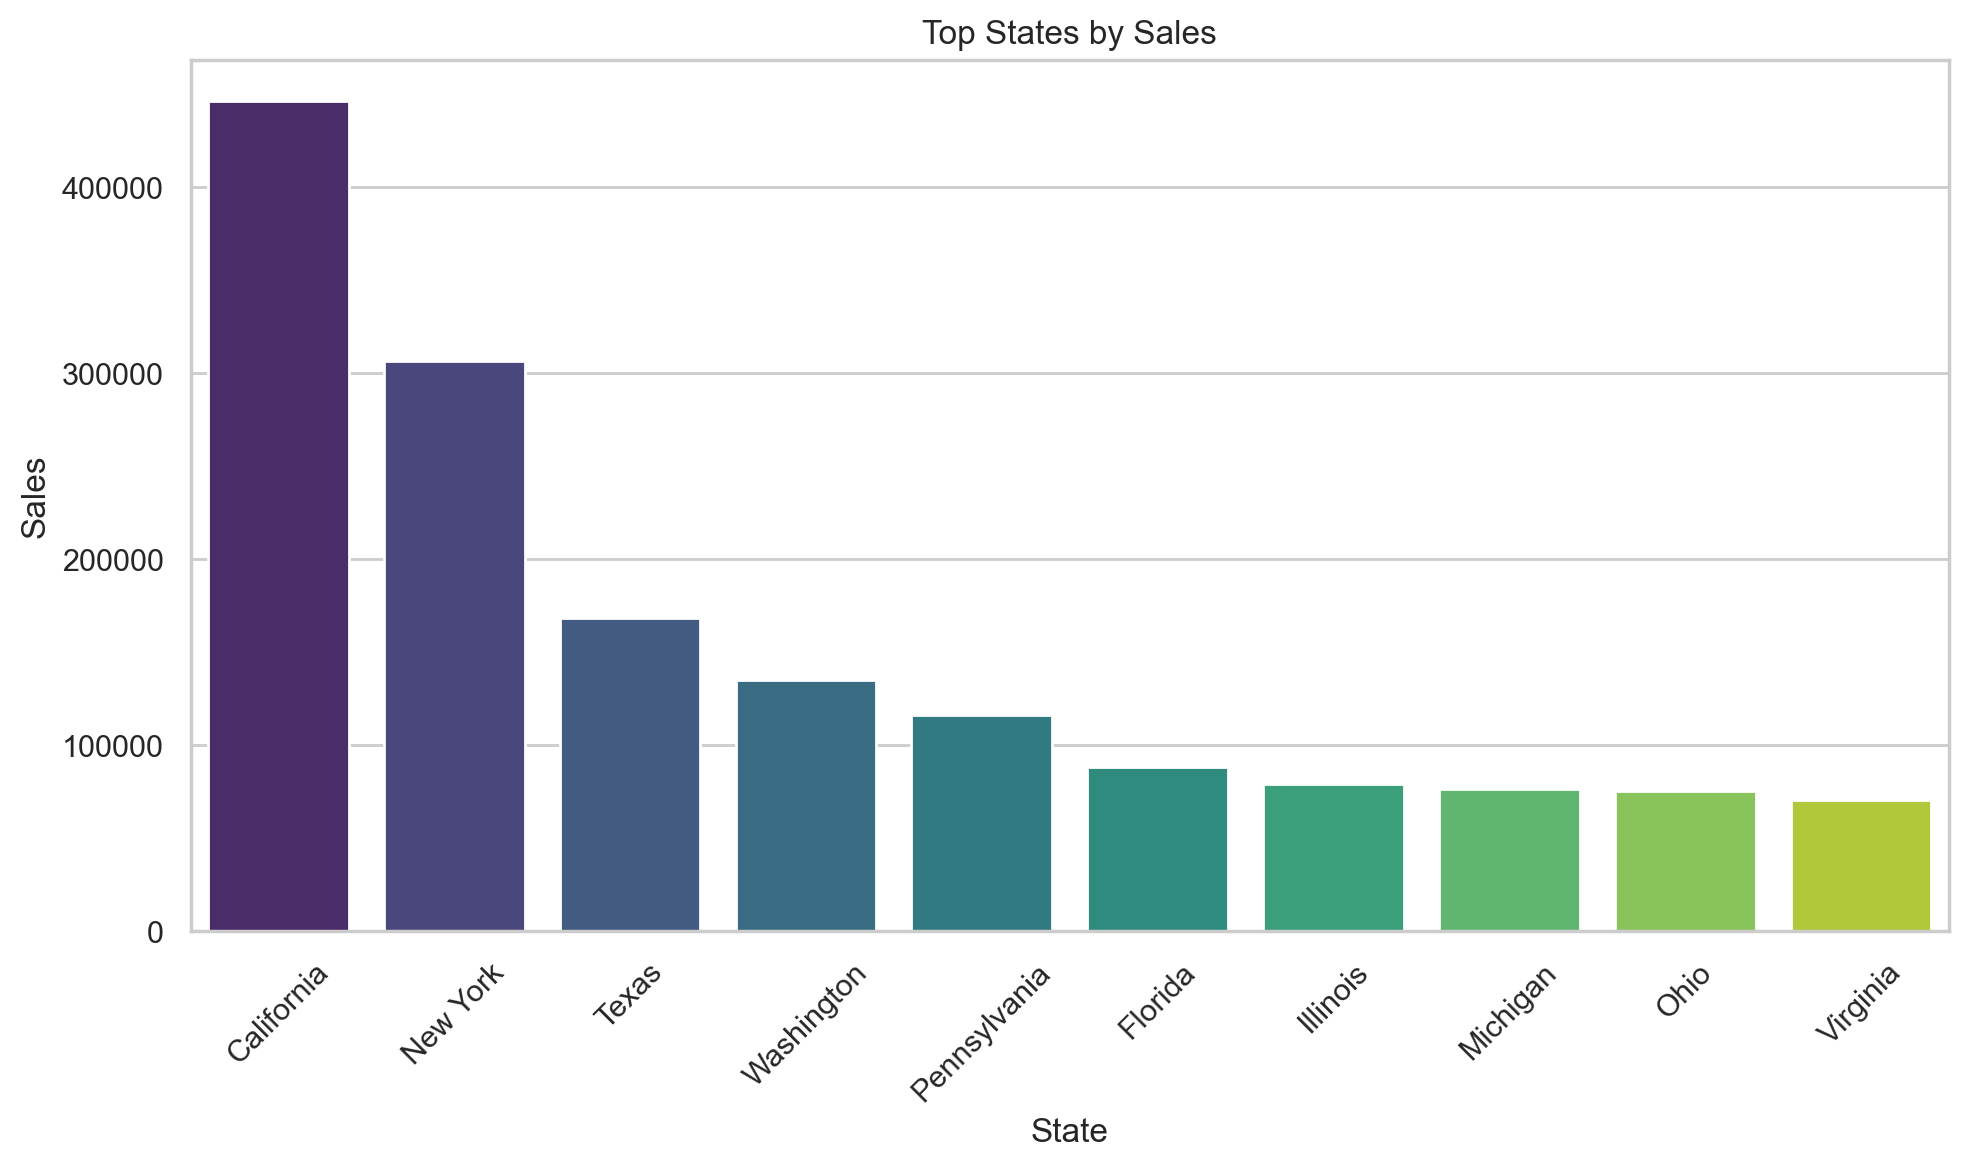

In [29]:
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='State', y='Sales', data=top_stats, hue='State',legend=False, palette='viridis')
plt.title('Top States by Sales')
plt.xlabel('State')
plt.ylabel('Sales')
#plt.yticks(rotation=90)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Total sales by region

In [30]:

top_regional_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).round(2).head(10)
top_regional_sales = top_regional_sales.reset_index()
top_regional_sales

,Region,Sales
0,West,710219.68
1,East,669518.73
2,Central,492646.91
3,South,389151.46


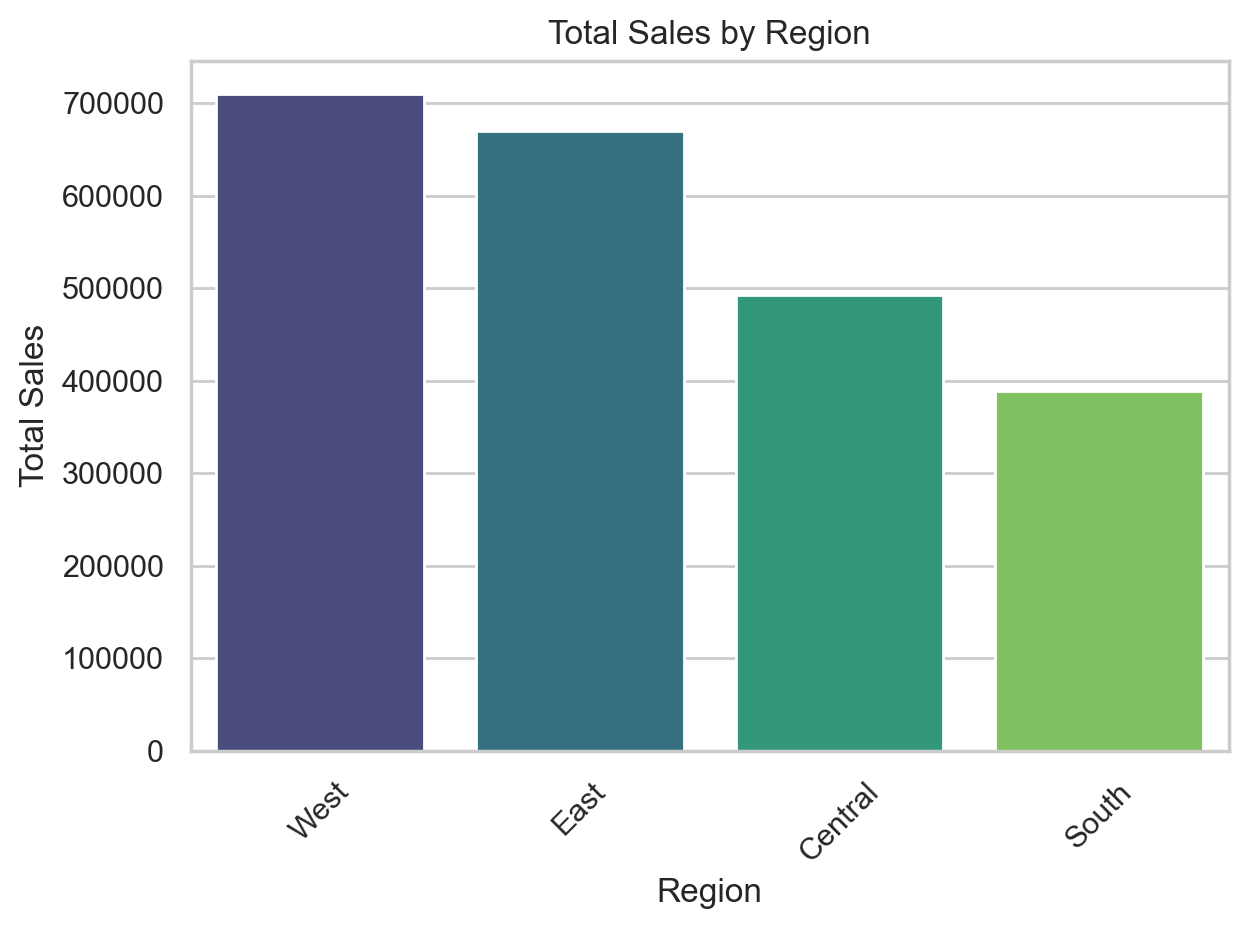

In [31]:
sns.barplot(data=top_regional_sales, x='Region', y='Sales', hue='Region', palette='viridis')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(5).round(2)
top_products = top_products.reset_index()
top_products

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.82
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38
2,Cisco TelePresence System EX90 Videoconferenci...,22638.48
3,HON 5400 Series Task Chairs for Big and Tall,21870.58
4,GBC DocuBind TL300 Electric Binding System,19823.48


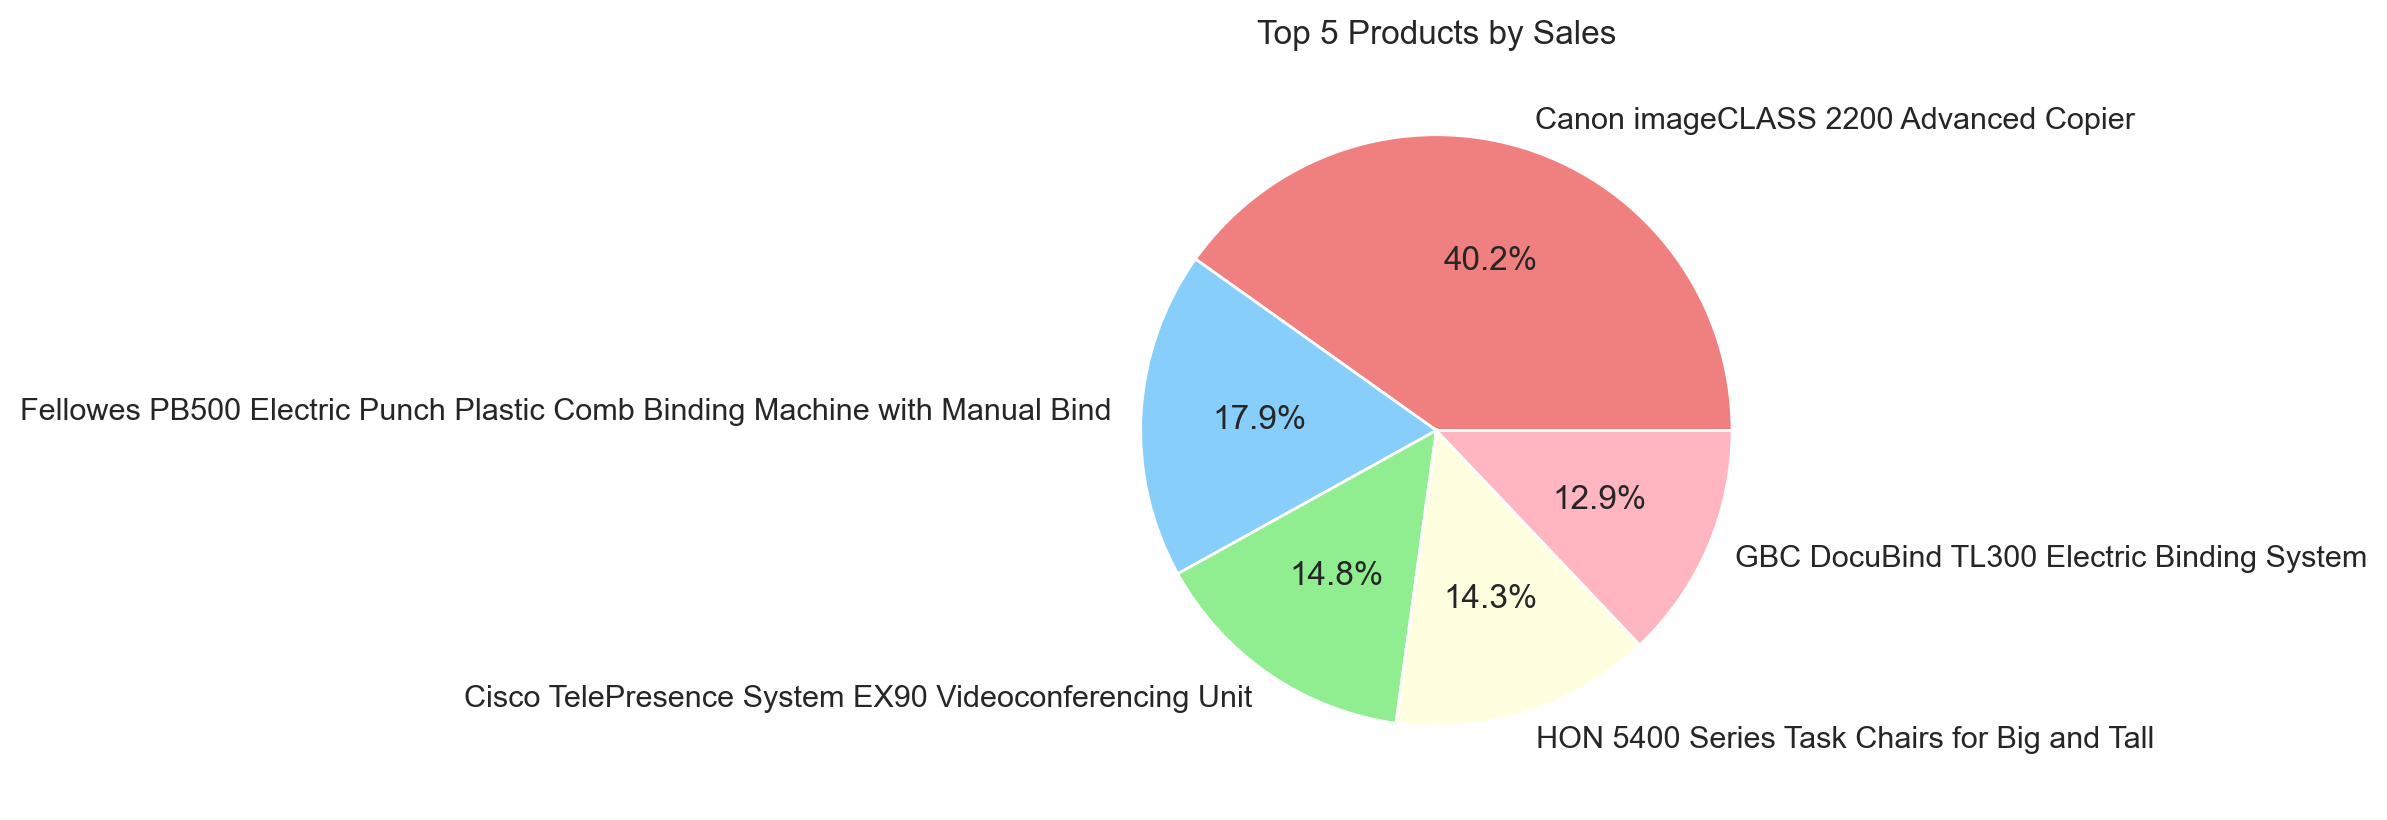

In [33]:
# plt.pie(top_products['Sales'], labels=top_products['Product Name'], autopct='%1.1f%%')

plt.pie(top_products['Sales'], labels=top_products['Product Name'], colors=['lightcoral', 'lightskyblue', 'lightgreen', 'lightyellow', 'lightpink'], autopct='%1.1f%%')
plt.title('Top 5 Products by Sales')
plt.show()

##### Yearly total sales

In [34]:
year_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum().round(2)
year_sales = year_sales.reset_index()
year_sales.columns = ['Year', 'Total Sales']
year_sales

,Year,Total Sales
0,2015,479856.21
1,2016,459436.01
2,2017,600192.55
3,2018,722052.02


##### Yearly sales distribution

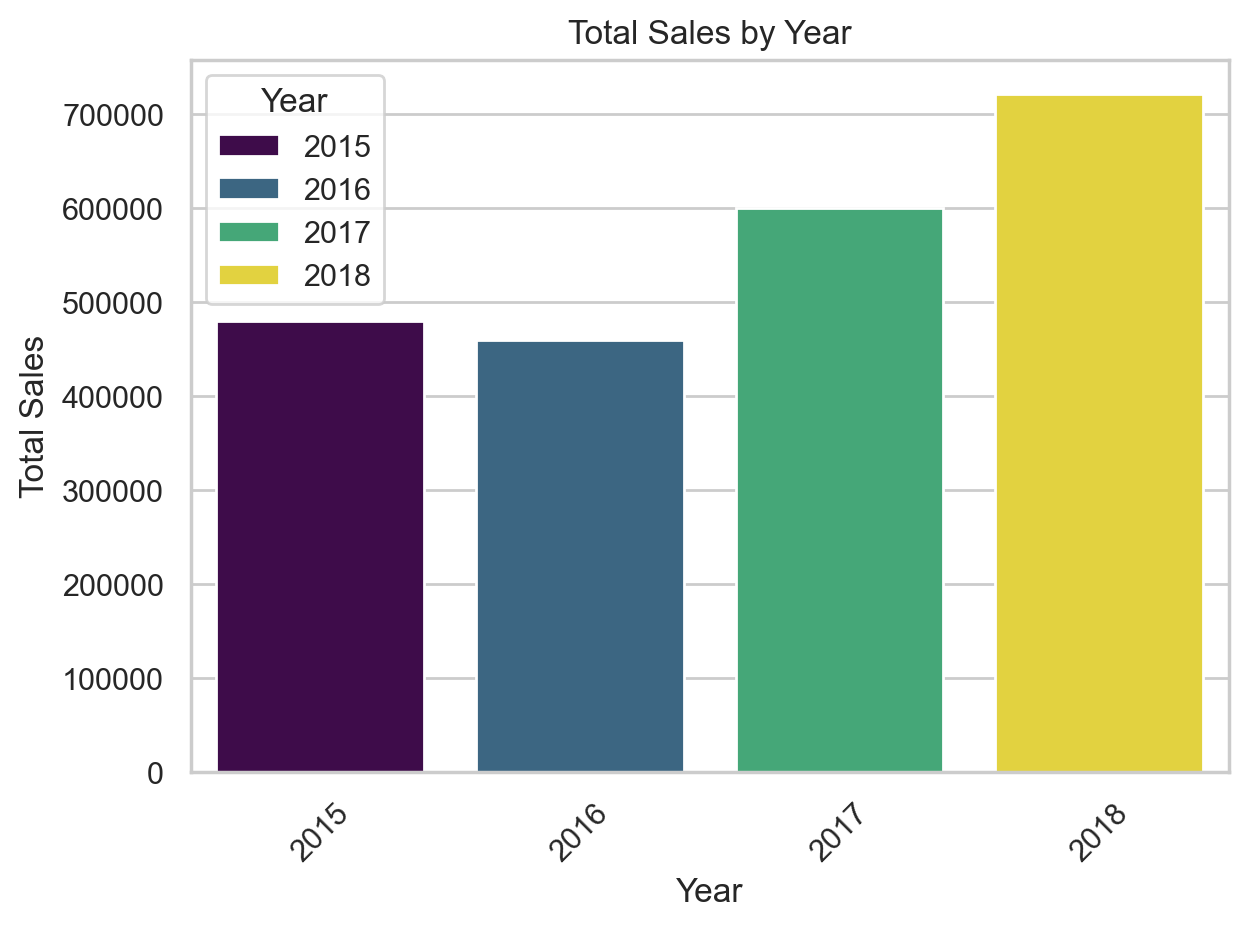

In [35]:
sns.barplot(data = year_sales, x='Year', y='Total Sales', hue='Year', palette='viridis')
plt.xticks(rotation=45)
plt.title('Total Sales by Year')
plt.tight_layout()
plt.show()

##### Total sales by category

<Axes: title={'center': 'Category Distribution'}, ylabel='Sales'>

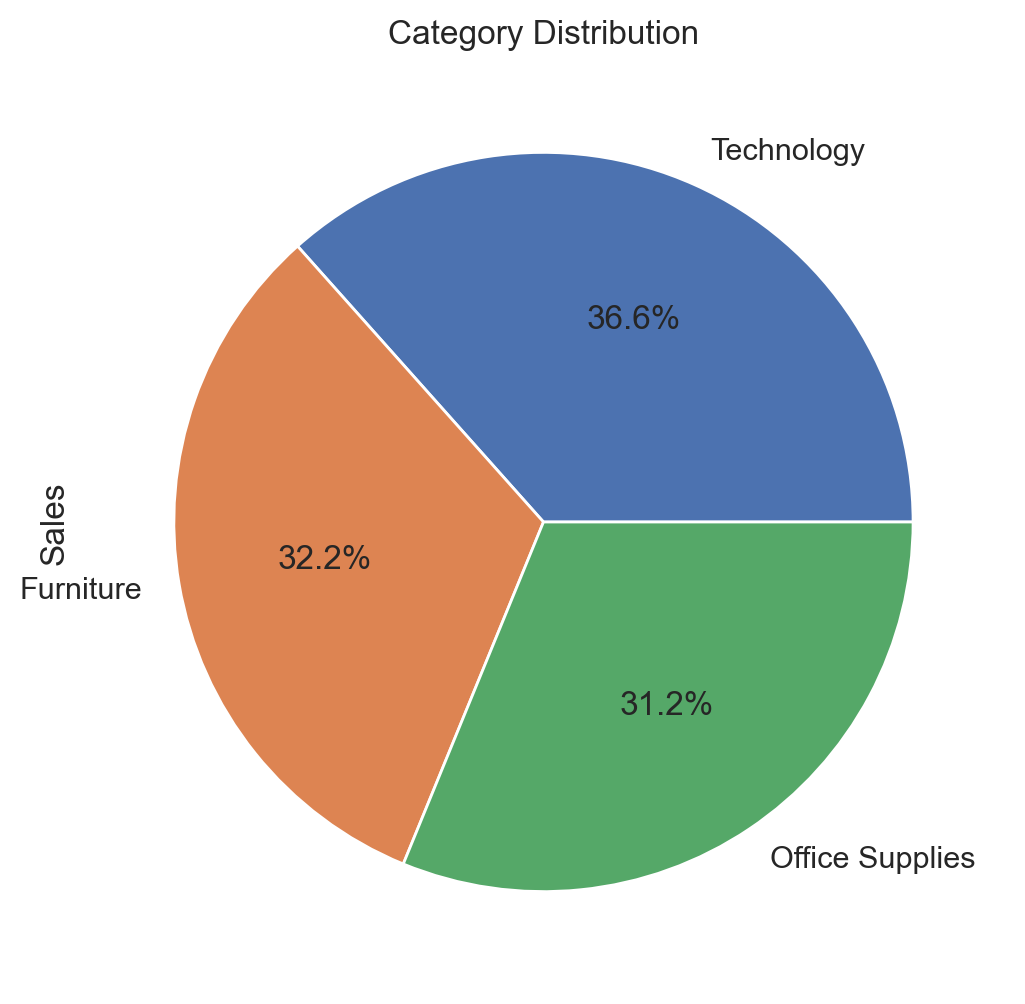

In [36]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False).plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), title='Category Distribution')

<Axes: title={'center': 'Sales by Category'}, xlabel='Category'>

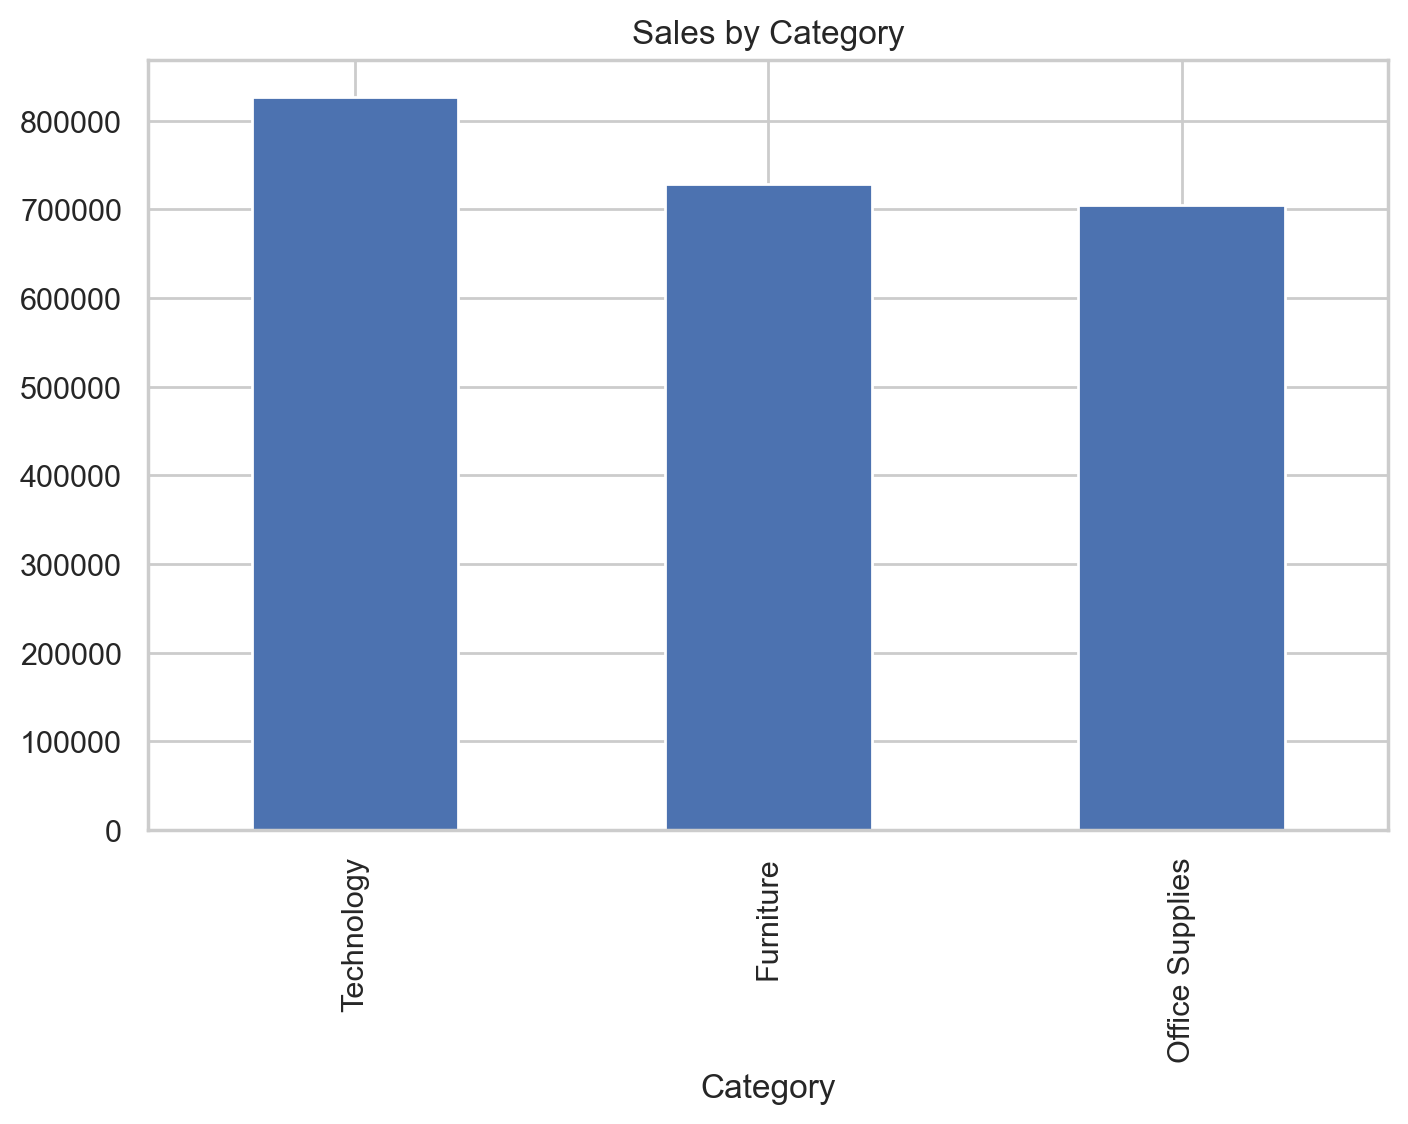

In [37]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False).plot(kind='bar', figsize=(8, 5), title='Sales by Category')

#####
Statistical summary on the sales column

In [38]:
df['Sales'].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

In [39]:
print(df['Sales'].describe())

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64


In [40]:
df['Sales'].dtype

dtype('float64')

In [41]:
invalid_sales = df[pd.to_numeric(df['Sales'], errors='coerce').isna()]
print(f'Total rows with invalid Sales values: {len(invalid_sales)}')

Total rows with invalid Sales values: 0


##### Verifying Data Uniformity

In [42]:
categorical_columns = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
print("--- Categorical Columns ---\n")

for cols in categorical_columns:
    # get uniques values and their count
    unique_values = df[cols].unique()
    unique_count = df[cols].nunique()

    print(f"Column: {cols} ({unique_count} unique values)")
    print(f"Unique Values: {unique_values}")
    print("-"*100)

--- Categorical Columns ---

Column: Ship Mode (4 unique values)
Unique Values: ['Second Class' 'Standard Class' 'First Class' 'Same Day']
----------------------------------------------------------------------------------------------------
Column: Segment (3 unique values)
Unique Values: ['Consumer' 'Corporate' 'Home Office']
----------------------------------------------------------------------------------------------------
Column: Region (4 unique values)
Unique Values: ['South' 'West' 'Central' 'East']
----------------------------------------------------------------------------------------------------
Column: Category (3 unique values)
Unique Values: ['Furniture' 'Office Supplies' 'Technology']
----------------------------------------------------------------------------------------------------
Column: Sub-Category (17 unique values)
Unique Values: ['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'


#### Confirmed absolute data uniformity across the text columns

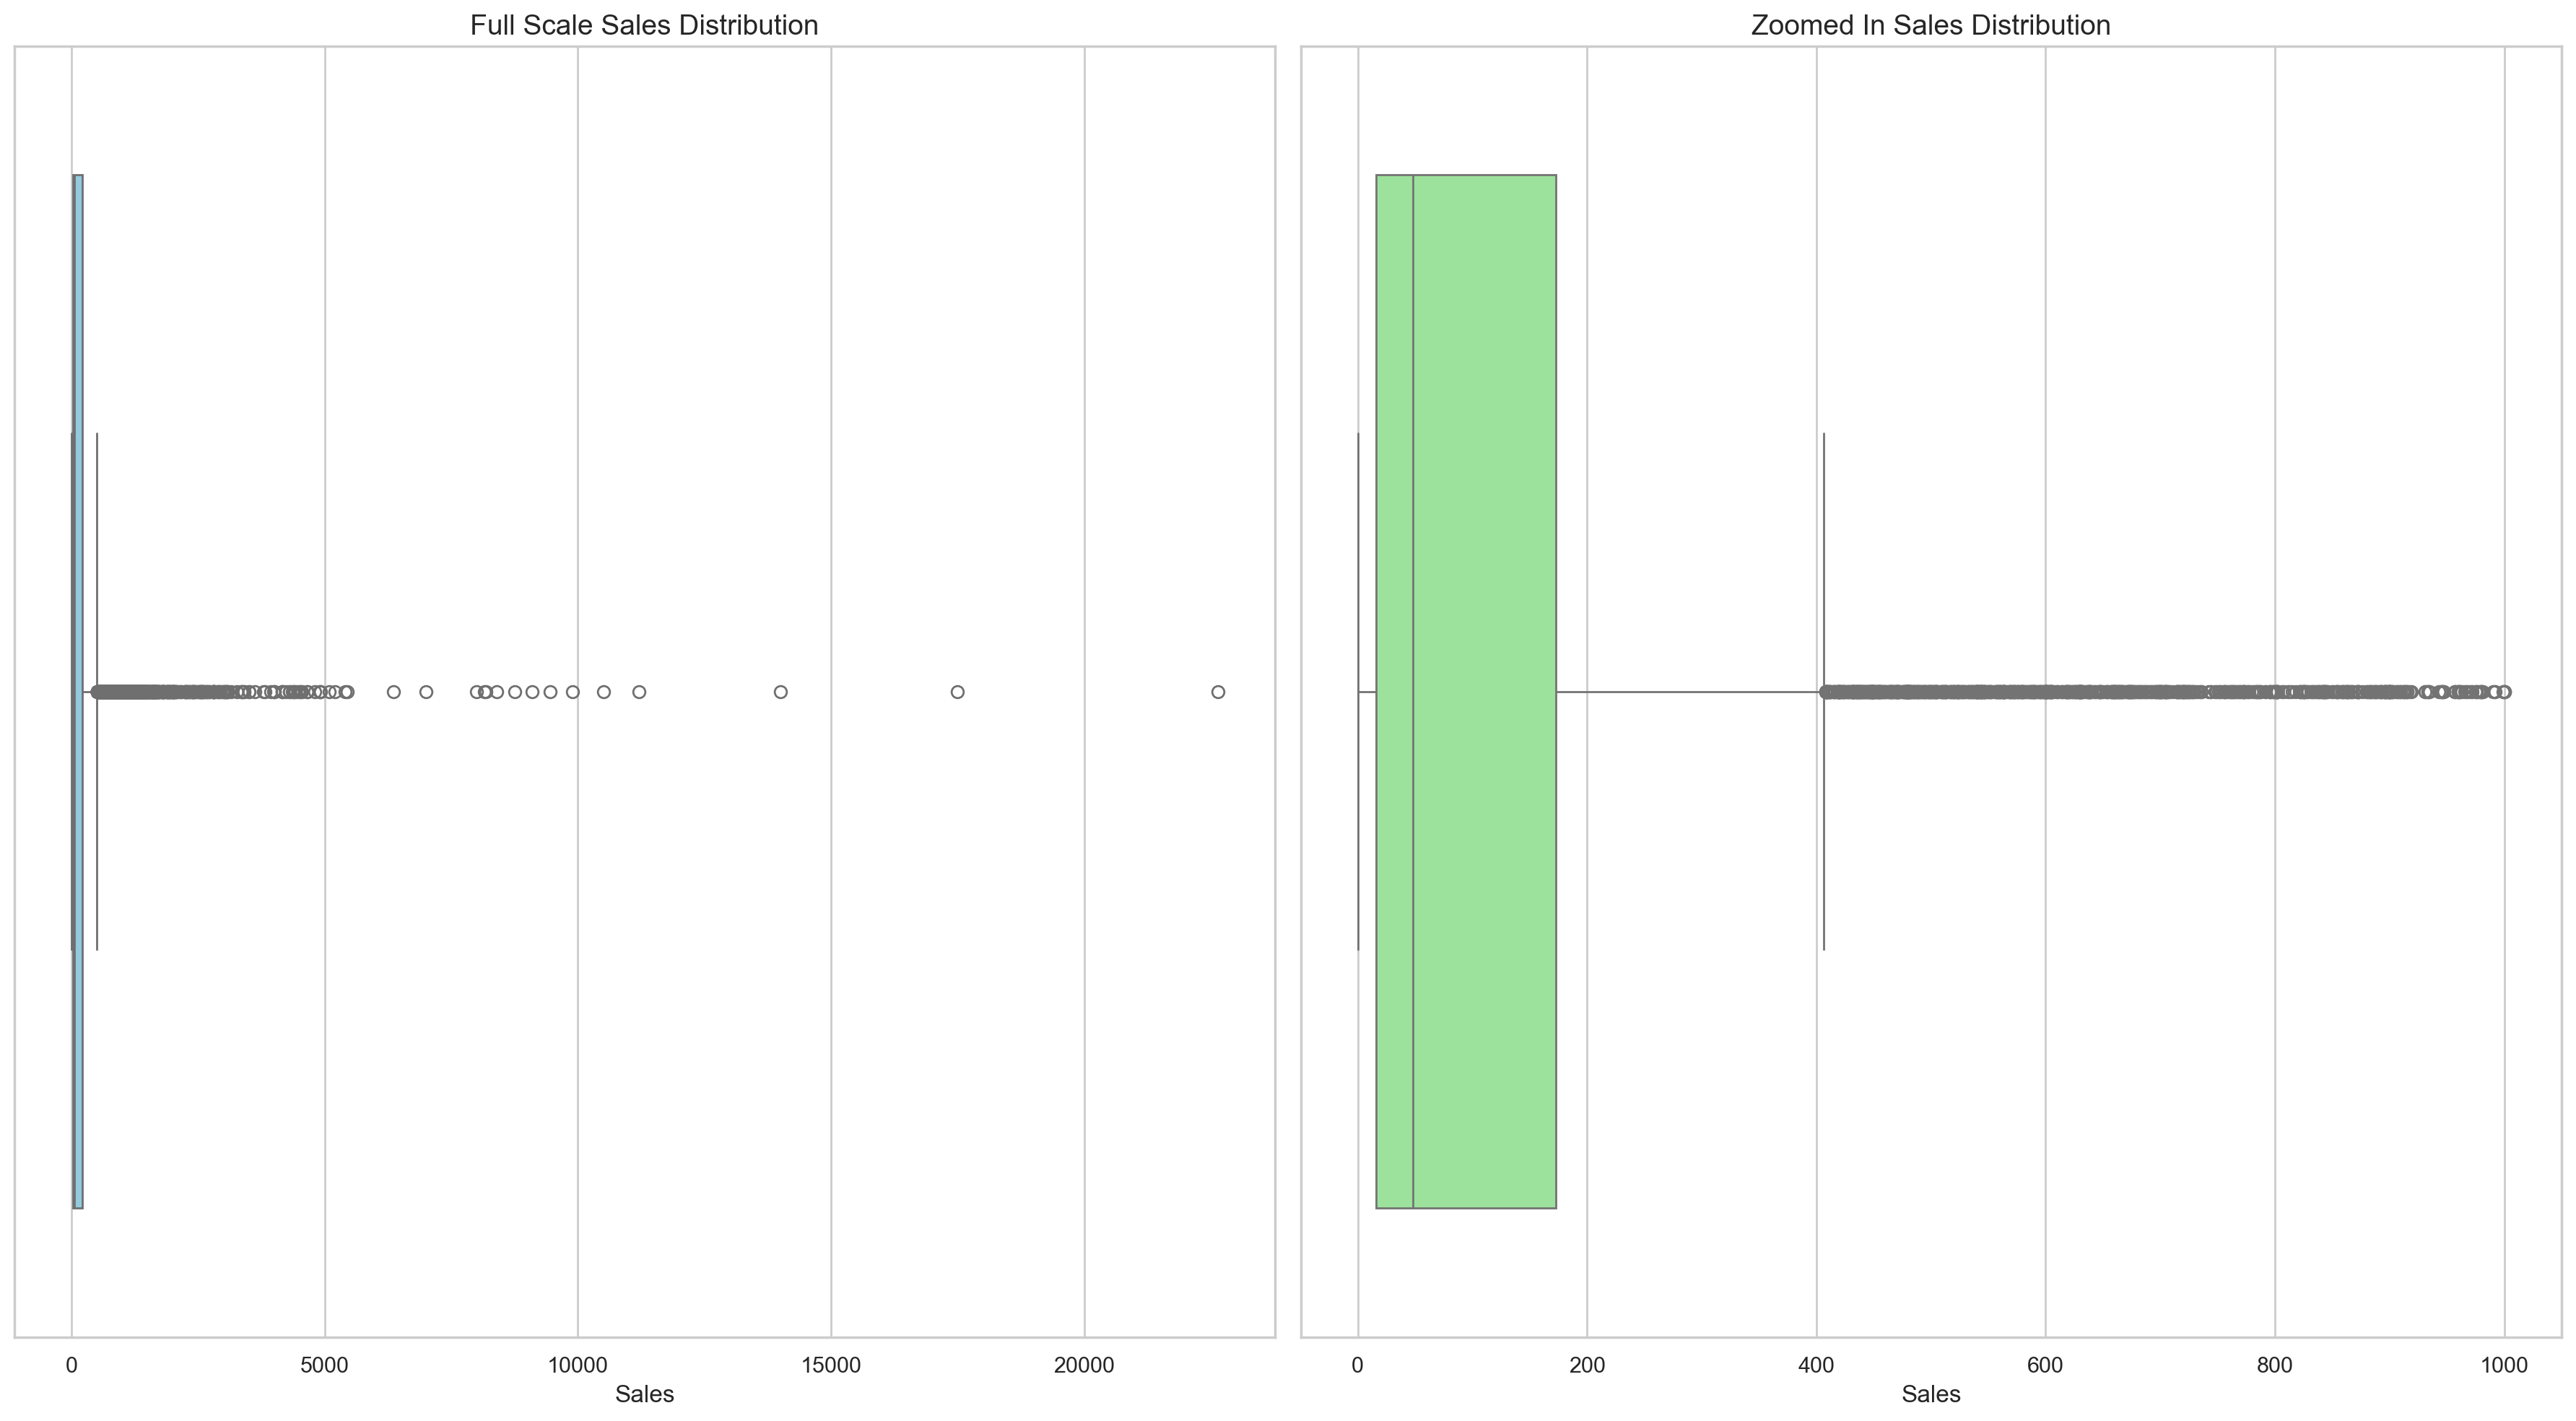

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
sns.boxplot(data=df, x='Sales', color='skyblue', ax=axes[0])
axes[0].set_title('Full Scale Sales Distribution', fontsize=14)
axes[0].set_xlabel('Sales')

sns.boxplot(data=df[df['Sales'] <= 1000], x='Sales', color='lightgreen', ax=axes[1])
axes[1].set_title('Zoomed In Sales Distribution', fontsize=14)
axes[1].set_xlabel('Sales')

plt.tight_layout()
plt.show()

##### Histogram and KDE
* The sales data shows an asymmetric bell curve that peaks near zero and rapiddly drops and stretches in a long tail to the right.

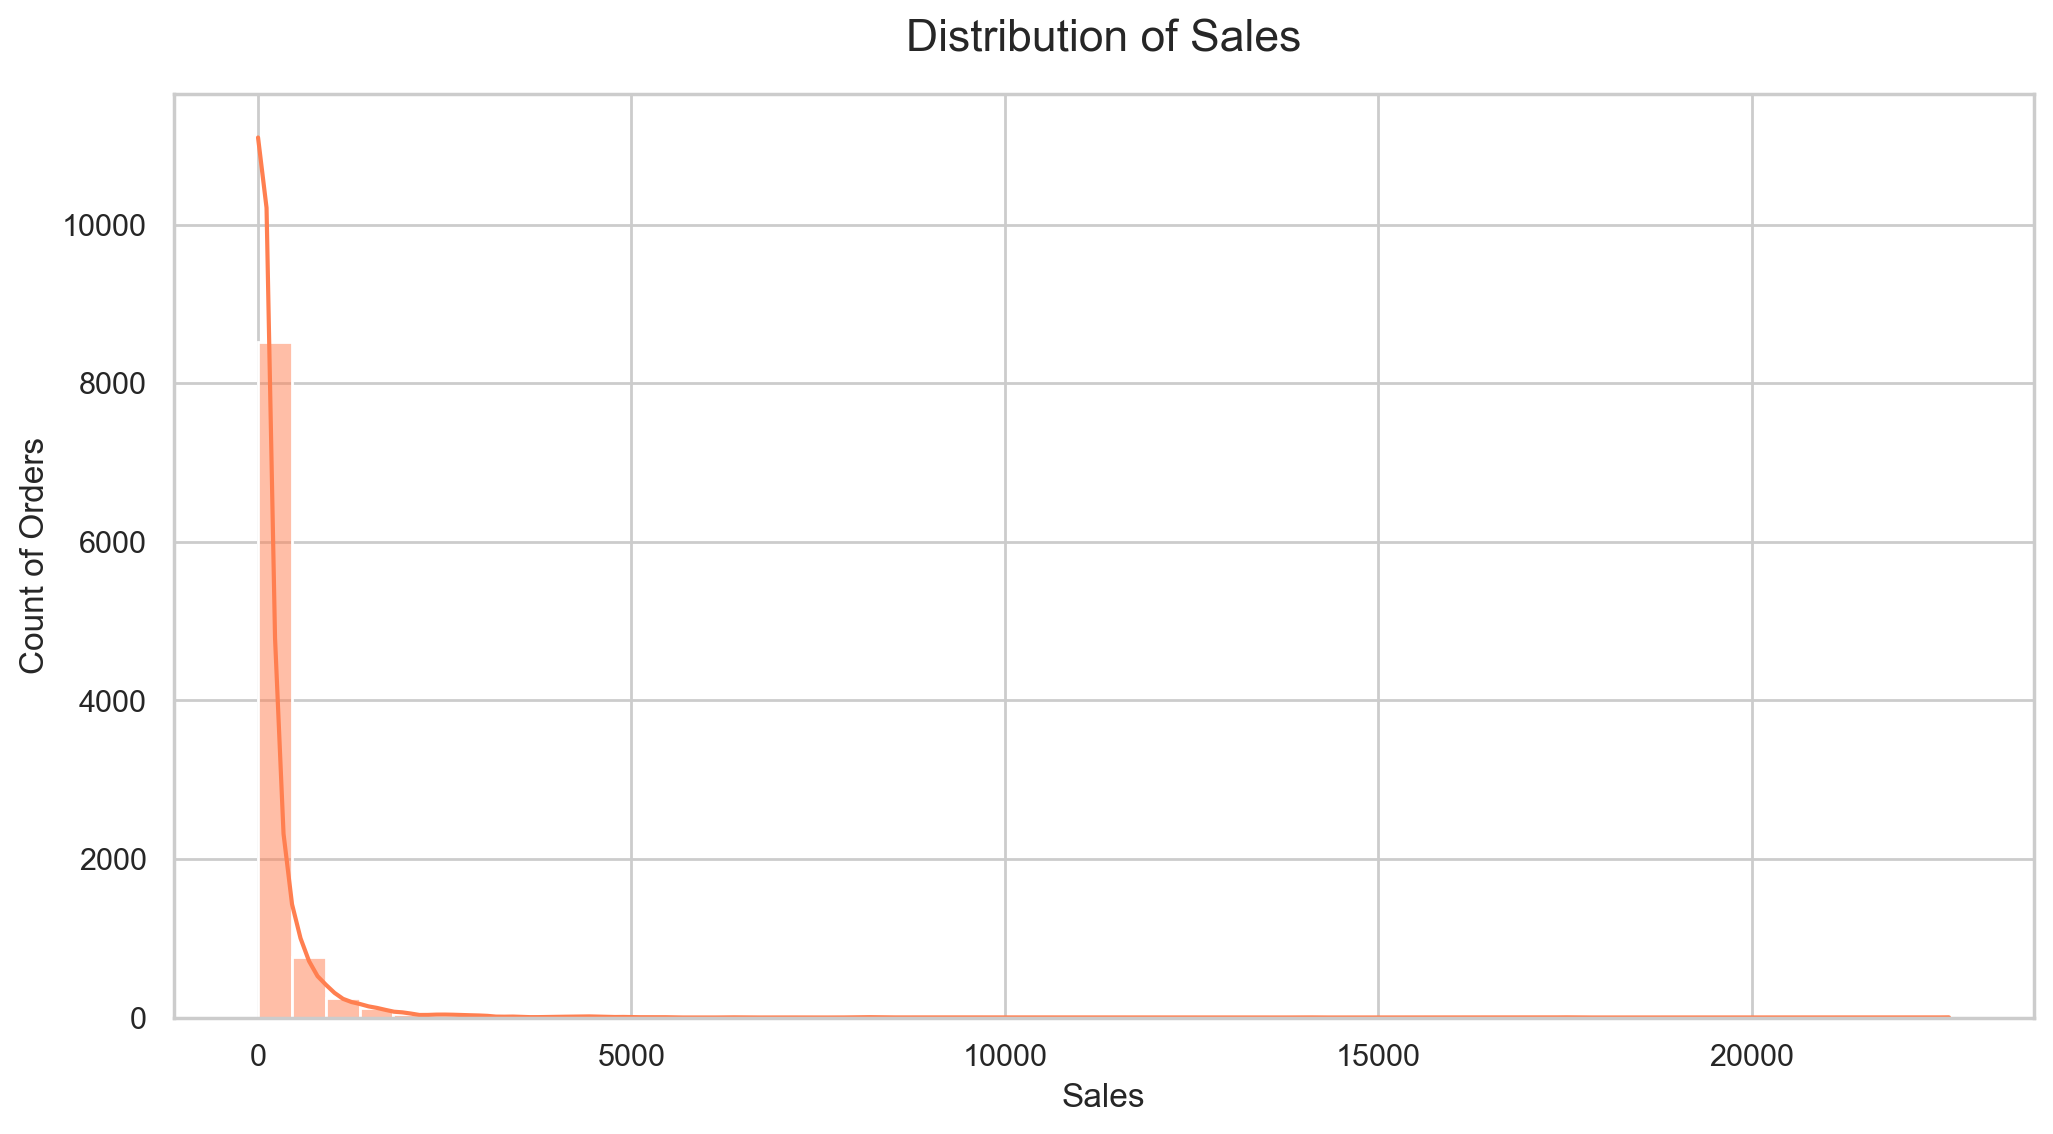

In [44]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Sales'], bins=50, kde=True, color='coral')
plt.title('Distribution of Sales', fontsize=16, pad=15)
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Count of Orders', fontsize=12)
plt.show()

##### Normalised extreme values with logarithmic scale
* We apply a logarithmic scale to make this highly readable and normalise the extreme values so that we see the true shape of the distribution.
* The orders with a sales amount of 22638 tends to flatten the curve.

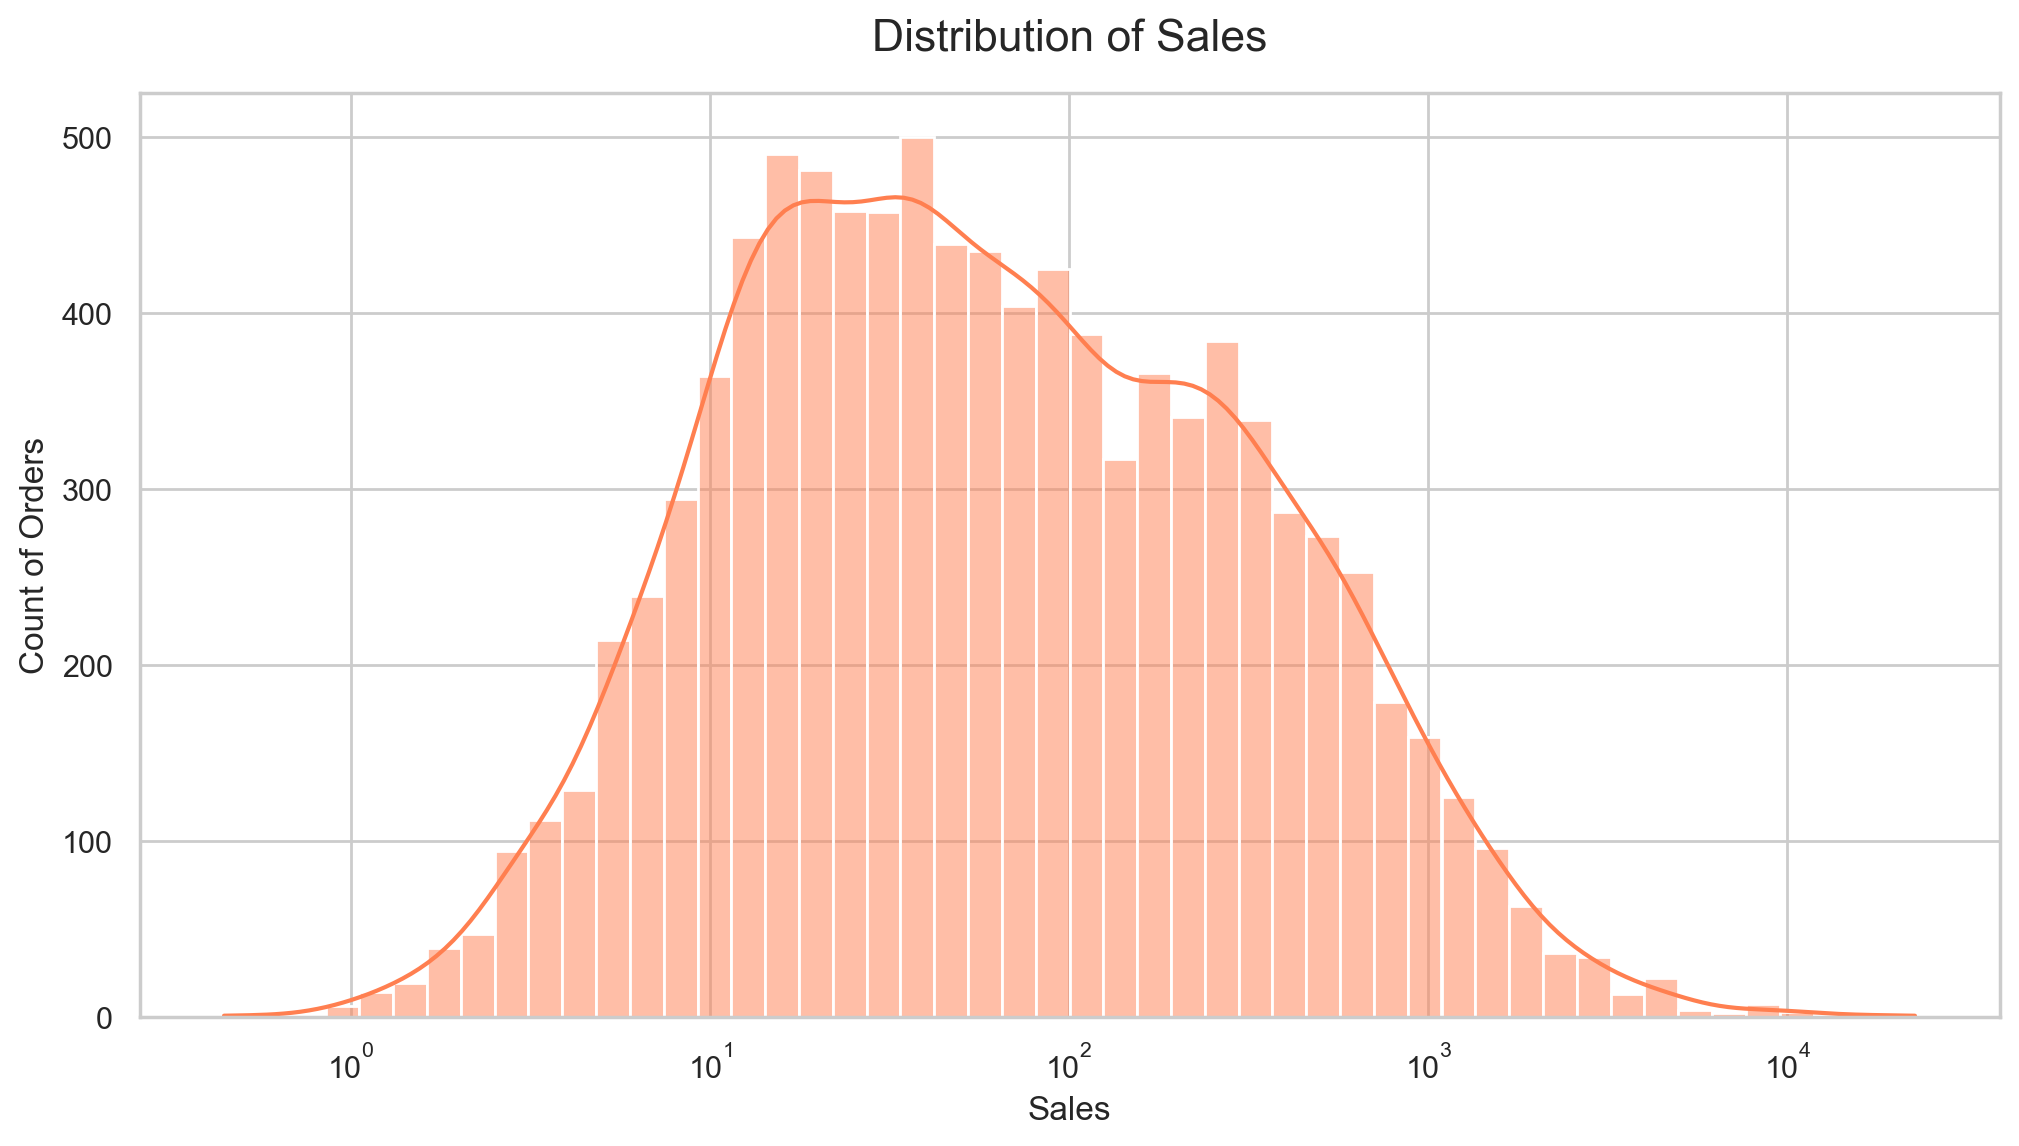

In [45]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Sales'], bins=50, kde=True,log_scale=True, color='coral')
plt.title('Distribution of Sales', fontsize=16, pad=15)
plt.xlabel('Sales', fontsize=12)
plt.ylabel('Count of Orders', fontsize=12)
plt.show()

##### Sales grouped by category

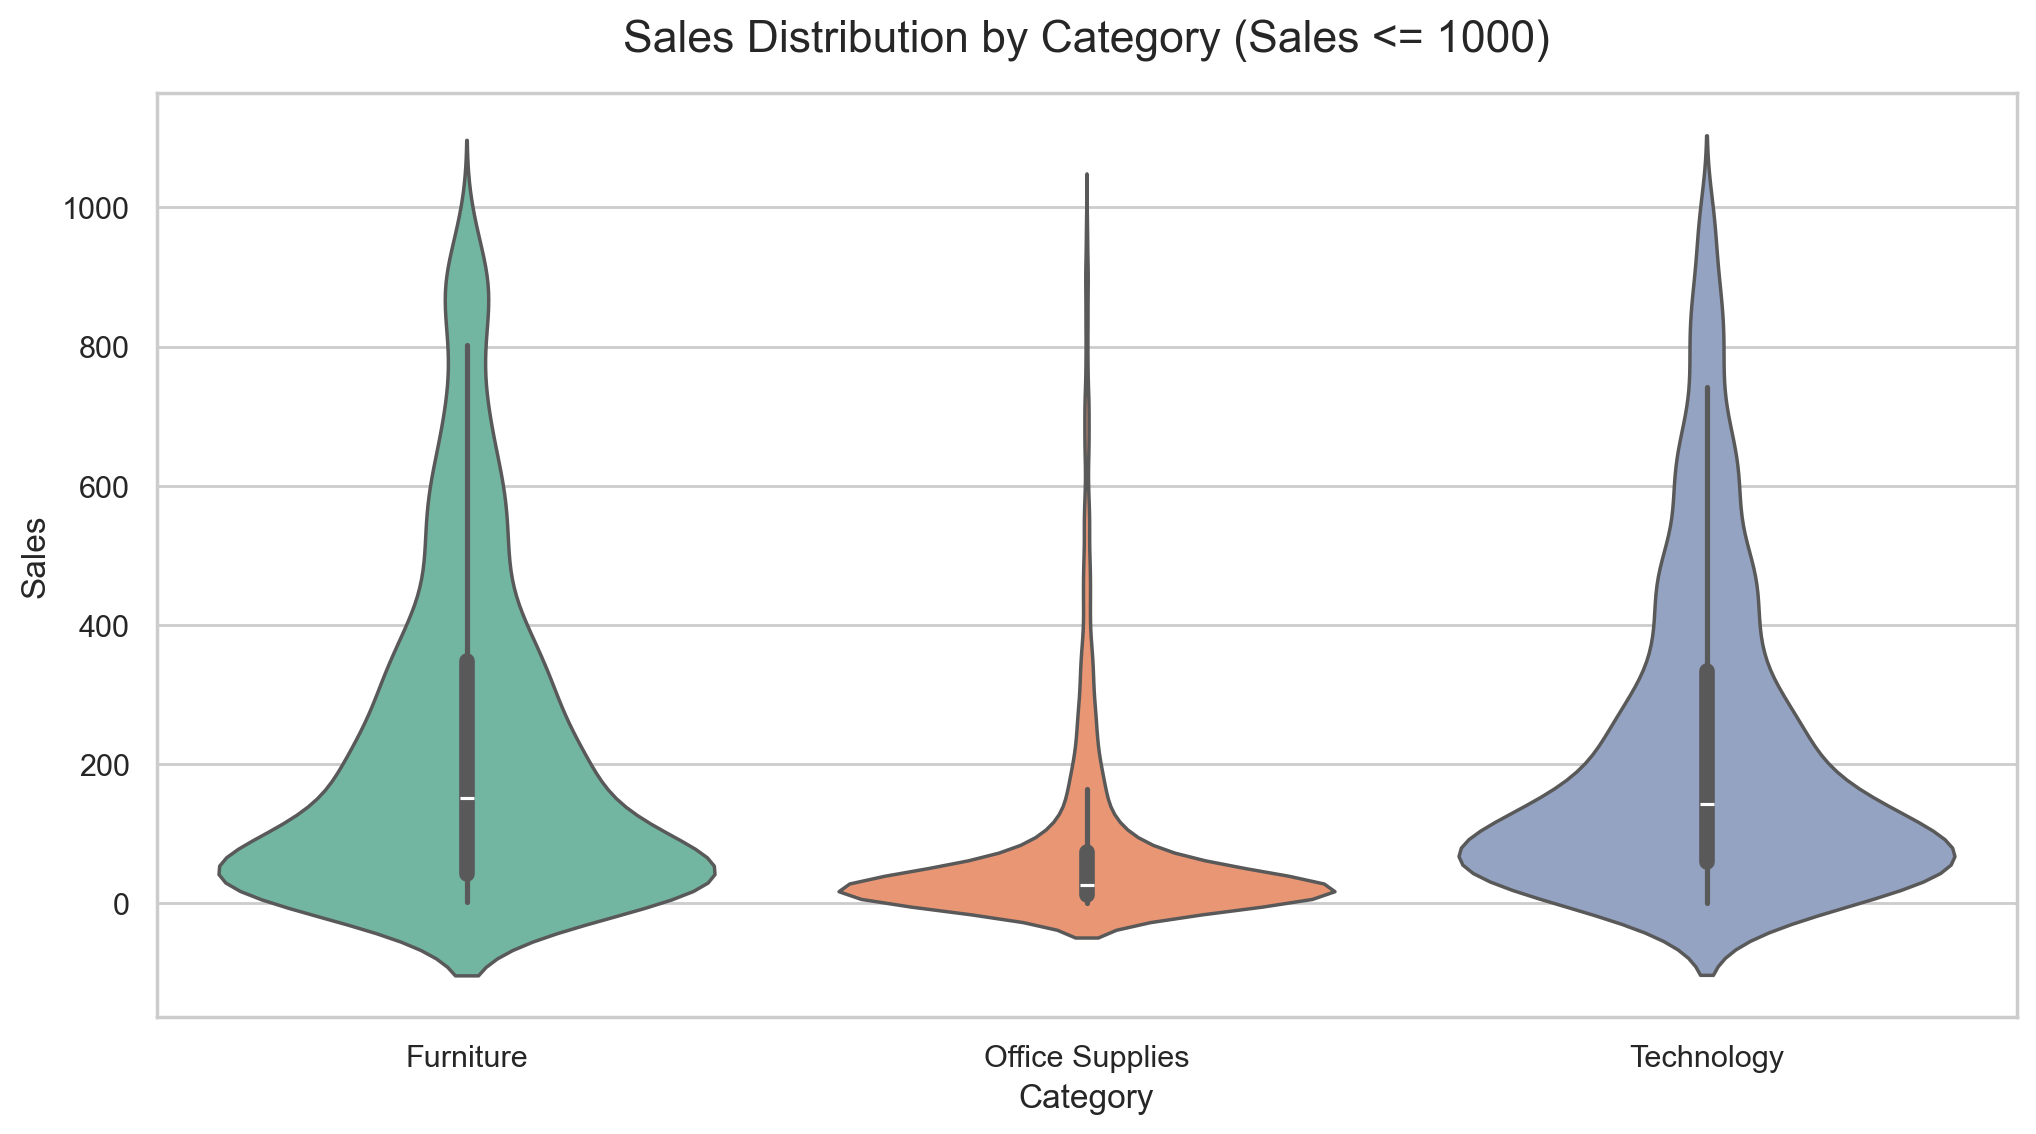

In [46]:
plt.figure(figsize=(12, 6))
df_filtered = df[df['Sales'] <= 1000]
sns.violinplot(data=df_filtered, x='Category', y='Sales', hue='Category', palette='Set2')
plt.title('Sales Distribution by Category (Sales <= 1000)', fontsize=16, pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.show()

##### Distribution of prices across a custom price tier

In [47]:
bins = [0, 20, 50, 200, 1000, float('inf')]
labels = ['Budget Tier ($0-$20)', 'Everyday Tier ($20-$50)', 'Mid-Range Tier ($50-$200)', 'Premium Tier ($200-$1000)', 'Enterprise Tier (>$1000)']

# Categorize each row into a tier
df['Sales_Tier'] = pd.cut(df['Sales'], bins=bins, labels=labels)

# Calculate counts and exact percentages
tier_counts = df['Sales_Tier'].value_counts()
tier_percentages = df['Sales_Tier'].value_counts(normalize=True) * 100

# Combine into a beautiful summary table
distribution_table = pd.DataFrame({
    'Number of Orders': tier_counts,
    'Percentage of Customers (%)': tier_percentages.round(2)
}).reindex(labels) # Keeps them in logical order

distribution_table.head()

,Number of Orders,Percentage of Customers (%)
Sales_Tier,,
Budget Tier ($0-$20),2798,28.55
Everyday Tier ($20-$50),1959,19.99
Mid-Range Tier ($50-$200),2506,25.57
Premium Tier ($200-$1000),2075,21.17
Enterprise Tier (>$1000),462,4.71


In [48]:
# df.to_csv(r'C:\Users\user\Documents\DATA_ANALYSIS\SQL\CSV\superstore_sales_clean.csv', index=False)

print("File successfully saved to disk!")

File successfully saved to disk!
